# 78 - Code Challenge: Supervised Denoising

**Section:** CNNs | **Prereqs:** `CNNs/DoAutoEncoders_CleanGaussians_(CNN_AE).ipynb` | **Next:** `CNN Milestone Projects/Fashion_MNIST.ipynb`

The previous notebook relied on the bottleneck to discard the occlusion as a side
effect. This one asks for it directly: input is the occluded image, target is the
clean one.

    loss = MSE(model(occluded), clean)

Because both versions of each image are generated, the pairing is exact. That
makes this ordinary supervised learning with an image as the target - the model is
told precisely what 'clean' means instead of having to infer it.

**Denoise-by-pairing is how real image restoration works:** super-resolution,
JPEG artifact removal, deblurring, and inpainting all train on (degraded, clean)
pairs, usually by degrading clean images synthetically - exactly what this
notebook does.

**Architecture note:** the decoder mirrors the encoder step for step, each
`ConvTranspose2d` undoing one downsampling stage (5 -> 11 -> 23 -> 46 -> 91). Getting
those sizes to land exactly right takes arithmetic, which is why the code carries
per-layer comments and why `torchsummary` is run before training.

**`Sigmoid` on the output** bounds it to [0,1]. The data here runs slightly
outside that range (Gaussian minus noise), so the model cannot reproduce the
extremes - a small mismatch worth noticing, and a reminder to match the output
activation to the target's actual range.

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset, Dataset

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

from torchsummary import summary

In [37]:
# The key difference from the previous notebook: TWO arrays are generated per
# sample from the same underlying blob -
#   images_no = clean (the target),
#   images    = the same image plus an occlusion bar (the input).
# Paired data like this is what turns denoising into a supervised problem.
img_size = 91
n = 2000

sigma = np.linspace(2,20,n)

x = np.linspace(-4,4,img_size)

X,Y = np.meshgrid(x,x)

images = np.zeros((n , 1, img_size,img_size), dtype=float)
images_no = np.zeros((n , 1, img_size,img_size), dtype=float)

for i in range(n):

  center = 2*np.random.randn(2)

  X_hat = X - center[0]
  Y_hat = Y - center[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i]))

  noise = np.random.randn(*G.shape) / 5

  images_no[i,:,:,:] = G - noise
  images[i,:,:,:] = G - noise

  # No Occulsion
  i1 = np.random.choice(np.arange(2,28))
  i2 = np.random.choice(np.arange(2,6))

  if np.random.randn() > 0:
    images[i,:,i1:i1+i2,:] = 1
  else:
    images[i,:,:,i1:i1+i2] = 1



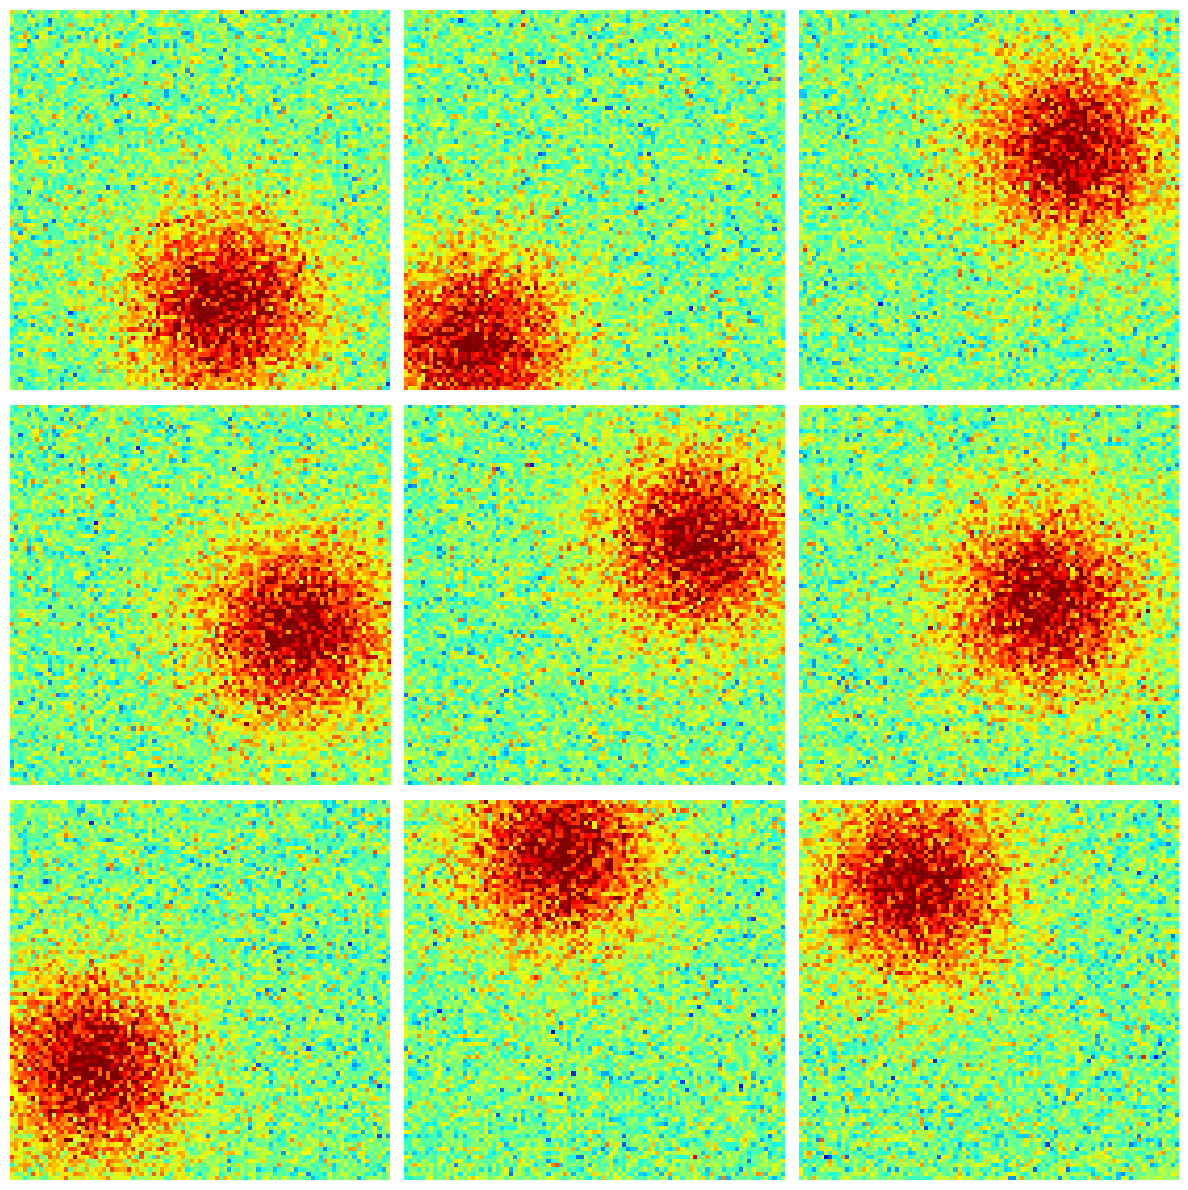

In [38]:
# The clean targets.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(n, len(ax))):
  ax[i].imshow(np.squeeze(images_no[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

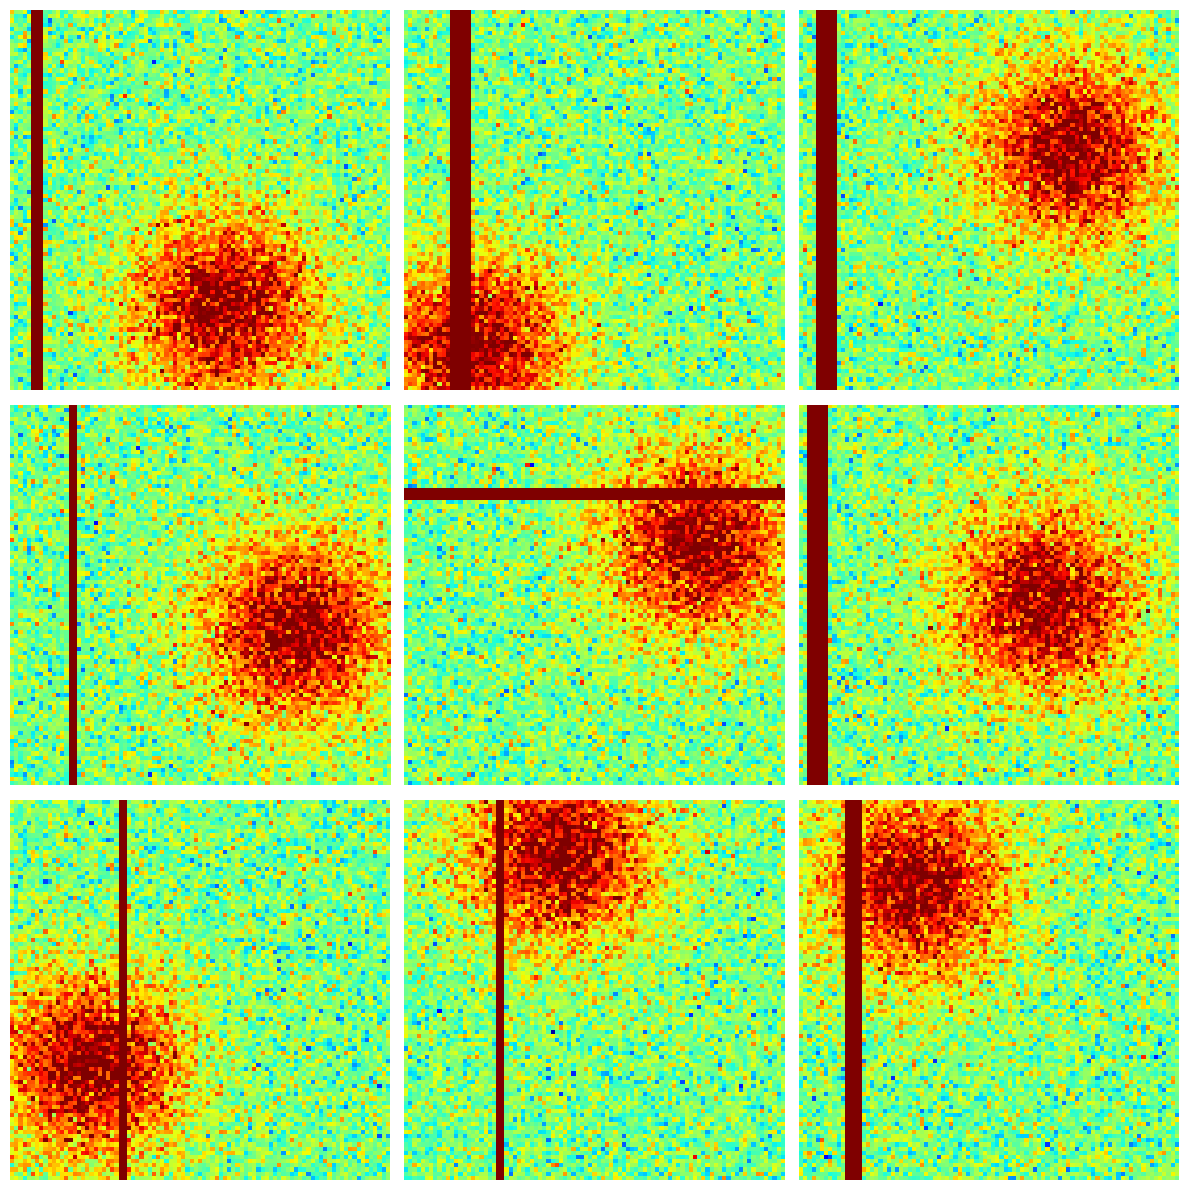

In [39]:
# The occluded inputs.
fig, ax = plt.subplots(3,3, figsize=(12,12))
ax = ax.flatten()


for i in range(min(n, len(ax))):
  ax[i].imshow(np.squeeze(images[i]), vmin=-1, vmax=1, cmap='jet')
  ax[i].axis('off')

plt.tight_layout()
plt.show()

In [40]:
# TensorDataset with TWO tensors: (occluded, clean). Unlike a plain autoencoder,
# the target is a different tensor from the input.
# Data Loader

device = ('cuda' if torch.cuda.is_available() else 'cpu')

train_tensor = torch.tensor(images, dtype=torch.float , device=device)

target_tensor = torch.tensor(images_no, dtype=torch.float , device=device)

train_dataset = TensorDataset(train_tensor,target_tensor)

bs = 8
train_loader = DataLoader(train_dataset ,batch_size=bs , drop_last=True, shuffle=True)

device

'cuda'

In [41]:
# A deeper autoencoder: 1 -> 32 -> 64 -> 128 down to 5x5, then back up.
# The decoder mirrors the encoder, each ConvTranspose2d undoing one downsampling
# step (5 -> 11 -> 23 -> 46 -> 91). The per-layer comments track those sizes,
# which is the only sane way to get transposed-convolution arithmetic right.
# Sigmoid bounds the output to [0,1]; the data runs slightly outside that, so
# the extremes cannot be reproduced exactly.
class AutoEncoder(nn.Module):
  def __init__(self):
    super().__init__()
    # Input.size = (1,91,91)
    self.enc = nn.Sequential(
        nn.Conv2d(1,32,kernel_size=3, padding=1,stride=2), # -> O.size = 46
        nn.ReLU(),
        nn.MaxPool2d((2,2)), # O.size = 23

        nn.Conv2d(32,64, kernel_size=3,padding=1,stride=1), # O.size = 23
        nn.ReLU(),
        nn.MaxPool2d((2,2)), # O.size = 11

        nn.Conv2d(64,128, kernel_size=3, padding=1, stride=1), # O.size = 11
        nn.ReLU(),
        nn.MaxPool2d((2,2)), # O.size = 5
    )

    # WE DONOT HAVE POOLING IN UPSAMPLING....
    self.dec = nn.Sequential(
        # 5 -> 11   (undo last MaxPool)
        nn.ConvTranspose2d(128, 64, kernel_size=3, stride=2, padding=0),
        nn.ReLU(),

        # 11 -> 23  (undo middle MaxPool)
        nn.ConvTranspose2d(64, 32, kernel_size=3, stride=2, padding=0),
        nn.ReLU(),

        # 23 -> 46  (undo first MaxPool)
        nn.ConvTranspose2d(32, 32, kernel_size=2, stride=2, padding=0),
        nn.ReLU(),

        # 46 -> 91  (undo first Conv stride 2)
        nn.ConvTranspose2d(32, 1, kernel_size=3, stride=2, padding=1),

        nn.Sigmoid()  # No activation on the final output layer (can add Sigmoid later if your input is [0,1])
    )


  def forward(self,x):

    x = self.enc(x)

    return self.dec(x)

In [42]:
# torchsummary - verify the output is really (1,91,91) before training.
test_model = AutoEncoder()
test_model.to(device)
summary(test_model, input_size=(1,91,91))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1           [-1, 32, 46, 46]             320
              ReLU-2           [-1, 32, 46, 46]               0
         MaxPool2d-3           [-1, 32, 23, 23]               0
            Conv2d-4           [-1, 64, 23, 23]          18,496
              ReLU-5           [-1, 64, 23, 23]               0
         MaxPool2d-6           [-1, 64, 11, 11]               0
            Conv2d-7          [-1, 128, 11, 11]          73,856
              ReLU-8          [-1, 128, 11, 11]               0
         MaxPool2d-9            [-1, 128, 5, 5]               0
  ConvTranspose2d-10           [-1, 64, 11, 11]          73,792
             ReLU-11           [-1, 64, 11, 11]               0
  ConvTranspose2d-12           [-1, 32, 23, 23]          18,464
             ReLU-13           [-1, 32, 23, 23]               0
  ConvTranspose2d-14           [-1, 32,

In [43]:
# Training: lossFunc(yhat, y) where x is occluded and y is clean.
# That is the whole difference from the previous notebook - the model is TOLD
# what clean looks like rather than inferring it from the bottleneck.
def train_model():

  model = AutoEncoder().to(device)

  lr = 1e-4
  epochs = 10

  lossFunc = nn.MSELoss()
  optimizer = torch.optim.Adam(model.parameters(),lr=lr)

  losses = []


  for epoch in range(epochs):

    model.train()
    batch_loss = []

    for x,y in train_loader:
      yhat = model(x)

      loss = lossFunc(yhat, y) # With Occulsion (Input) compared with wihtout occulsion.
      batch_loss.append(loss.item())

      optimizer.zero_grad()
      loss.backward()
      optimizer.step()


    losses.append(np.mean(batch_loss))

    if epoch % 10 == 0 or epoch == epochs - 1:
      print(f'Epoch : {epoch} | loss : {losses[epoch]} ')

  return model, losses

In [44]:
model, losses = train_model()

Epoch : 0 | loss : 0.0931637279689312 
Epoch : 9 | loss : 0.04112171736359596 


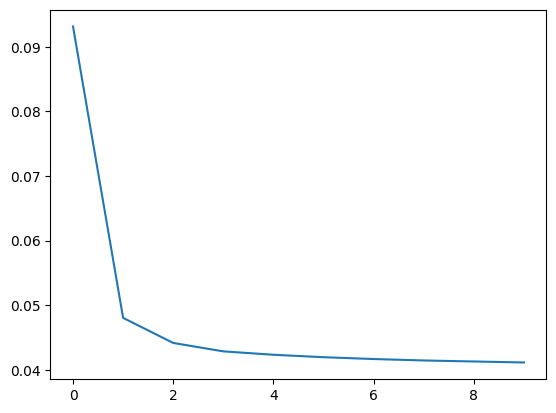

In [45]:
# Loss curve.
plt.plot(losses);

## Testing


In [46]:
# A fresh test set of 200 occluded images the model has never seen.
img_size = 91
n = 200

sigma = np.linspace(2,20,n)

x = np.linspace(-4,4,img_size)

X,Y = np.meshgrid(x,x)

images = np.zeros((n , 1, img_size,img_size), dtype=float)

for i in range(n):

  center = 2*np.random.randn(2)

  X_hat = X - center[0]
  Y_hat = Y - center[1]

  G = np.exp(-(X_hat ** 2 + Y_hat**2) / (2*sigma[i]))

  noise = np.random.randn(*G.shape) / 5

  images[i,:,:,:] = G - noise

  # Occulsion
  i1 = np.random.choice(np.arange(2,28))
  i2 = np.random.choice(np.arange(2,6))

  if np.random.randn() > 0:
    images[i,:,i1:i1+i2,:] = 1
  else:
    images[i,:,:,i1:i1+i2] = 1

In [47]:
device = ('cuda' if torch.cuda.is_available() else 'cpu')

test_tensor = torch.tensor(images, dtype=torch.float , device=device)

test_dataset = TensorDataset(test_tensor)

bs = 16
test_loader = DataLoader(test_dataset ,batch_size=test_dataset.tensors[0].shape[0])


In [48]:
# Reconstructions on the test set.
X = next(iter(test_loader))

output = model(X[0])

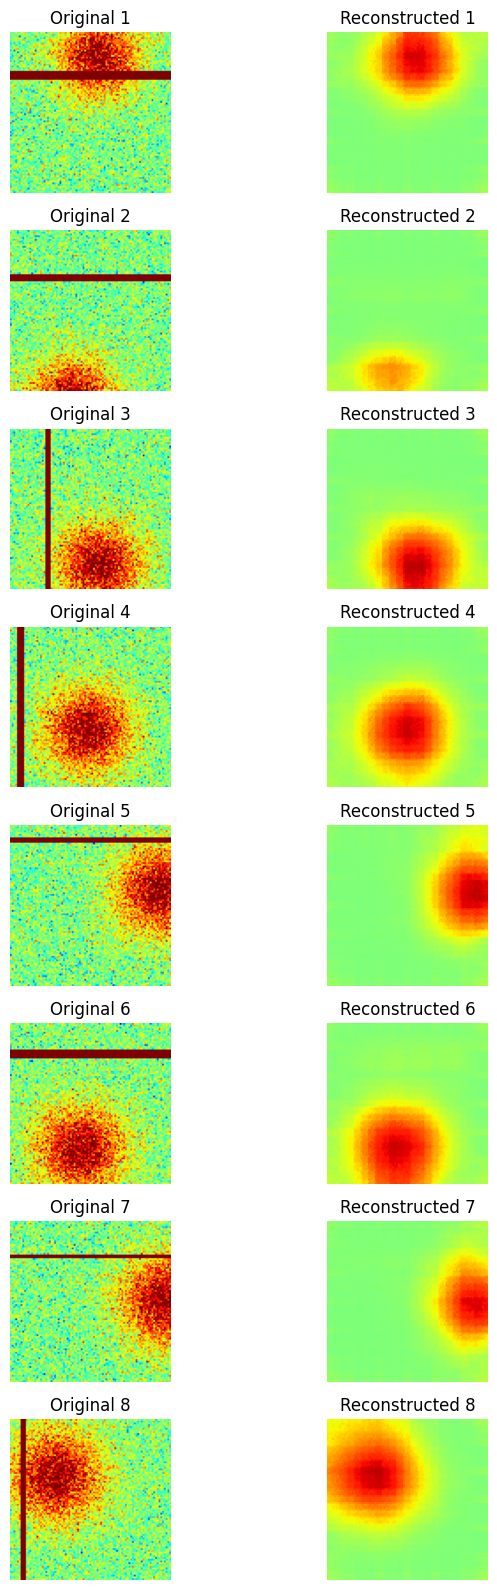

In [51]:
# Occluded input (left) vs reconstruction (right).
# The bars should be gone and the underlying Gaussian restored - cleaner than the
# unsupervised version, because the target said exactly what to produce.
# This is the same recipe used for real denoising, super-resolution and
# inpainting: generate (degraded, clean) pairs and train on them.
num_images_to_display = 8

# Move tensors to CPU and convert to numpy for plotting
input_images_np = X[0].detach().cpu().numpy()
output_images_np = output.detach().cpu().numpy()

fig, axes = plt.subplots(num_images_to_display, 2, figsize=(8, num_images_to_display * 2))

for i in range(num_images_to_display):
    # Plot original image
    axes[i, 0].imshow(np.squeeze(input_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 0].set_title(f'Original {i+1}')
    axes[i, 0].axis('off')

    # Plot reconstructed image
    axes[i, 1].imshow(np.squeeze(output_images_np[i]), cmap='jet', vmin=-1, vmax=1)
    axes[i, 1].set_title(f'Reconstructed {i+1}')
    axes[i, 1].axis('off')

plt.tight_layout()
plt.show()

## Conclusion:

Smaller Bottle neck layers genrally remove non repeating trends.. Like occulsions..

### Conclusion

This notebook demonstrates the effectiveness of an AutoEncoder in image denoising and occlusion removal. By training the model to reconstruct clean images from occluded inputs, we observe that the bottleneck layers successfully learn to represent the underlying image structure, effectively filtering out the added noise and occlusions. The visual comparison between the original occluded images and the reconstructed outputs clearly shows the model's ability to recover the unoccluded Gaussian shapes, highlighting the power of AutoEncoders for tasks involving data restoration and feature learning.